Como obter e representar a rede viária da área de estudo?

### Download e preparação da rede viária

Este notebook realiza o download da rede viária de uma área de Porto Alegre utilizando o OpenStreetMap através da biblioteca OSMnx.

Resultado esperado:

- Rede viária
- Nós
- Segmentos
- Arquivos GeoPackage

In [9]:
import sys
from pathlib import Path

# adiciona a raiz do projeto ao Python
sys.path.append(str(Path.cwd().parent))

In [14]:
# Bibliotecas
import osmnx as ox
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import importlib
import json

In [10]:
# Importa metodos
import src.classification as classification
import src.visualization as visualization
#from src.classification import classify_road_type
#from src.classification import classify_network

In [11]:
# Recarrega biblioteca para pegar as alterações recentes
importlib.reload(classification)
importlib.reload(visualization)

<module 'src.visualization' from 'c:\\Users\\Simone\\Documents\\GitHub\\EtPilot\\src\\visualization.py'>

In [12]:
# Configuracoes osmnx
ox.settings.use_cache = True
ox.settings.log_console = True

In [ ]:
# Carrega o arquivo de json de configuração
#   open -> inputs: arquivo, modo de abertura, codificação
with open("../config.json", "r", encoding="utf-8") as config_file:
    config = json.load(config_file)

# Configurações
study_area = config["study_area"]

cidade = study_area["place"]
network_type = study_area["network_type"]

# Escolha do bairro (primeiro da lista)
bairro = study_area["districts"][0]

# Monta a string
place = f"{bairro}, {cidade}"


In [19]:
# Selecao da regiao de interesse
#place = "Bom Fim, Porto Alegre, Rio Grande do Sul, Brazil"

graph = ox.graph_from_place(
    place,
    network_type="drive"
)

ox.save_graphml(graph, "../data/graph/rede-bomFim.graphml")

In [ ]:
# Informacoes da rede/grafo
print(graph)
print(f"Nós: {len(graph.nodes)}")
print(f"Arestas: {len(graph.edges)}")

MultiDiGraph with 55 nodes and 90 edges
Nós: 55
Arestas: 90


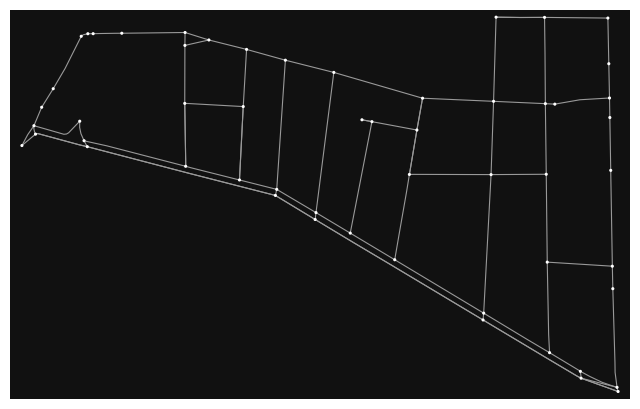

In [ ]:
# Plota o grafo
fig, ax = ox.plot_graph(
    graph,
    node_size=5,
    edge_linewidth=0.8
)

In [ ]:
# Converte para GeoDataFrames
gdf_nodes, gdf_edges = ox.graph_to_gdfs(graph)

In [ ]:
gdf_nodes.head()

,y,x,highway,street_count,geometry
osmid,,,,,
295523329,-30.036609,-51.209050,traffic_signals,3,POINT (-51.20905 -30.03661)
295523686,-30.035560,-51.211061,traffic_signals,4,POINT (-51.21106 -30.03556)
295523692,-30.034599,-51.212912,NaN,3,POINT (-51.21291 -30.0346)
295523695,-30.034119,-51.213837,crossing,3,POINT (-51.21384 -30.03412)
295523697,-30.033750,-51.214550,traffic_signals,4,POINT (-51.21455 -30.03375)


In [ ]:
gdf_edges.head()
# gdf_edges.plot()
# gdf_edges.to_file("edges.shp")

osmid      highway lanes maxspeed  \
u         v          key                                          
295523329 842729634  0    444002074      primary     3       60   
295523686 3329365567 0    206771856     tertiary     3       30   
          295523692  0    230519097      primary     2       60   
295523692 295523695  0    477174182      primary     2       60   
295523695 299852924  0     27318169  residential   NaN      NaN   

                                            name  oneway  reversed  \
u         v          key                                             
295523329 842729634  0    Avenida Osvaldo Aranha    True     False   
295523686 3329365567 0      Rua Fernandes Vieira    True     False   
          295523692  0    Avenida Osvaldo Aranha    True     False   
295523692 295523695  0    Avenida Osvaldo Aranha    True     False   
295523695 299852924  0           Avenida Cauduro    True     False   

                              length  \
u         v          key               
295523329 842729634  0     72.170172   
295523686 3329365567 0     13.735895   
          295523692  0    207.776893   
295523692 295523695  0    103.834681   
295523695 299852924  0    227.381495   

                                                                   geometry  \
u         v          key                                                      
295523329 842729634  0    LINESTRING (-51.20905 -30.03661, -51.20907 -30...   
295523686 3329365567 0    LINESTRING (-51.21106 -30.03556, -51.21107 -30...   
          295523692  0    LINESTRING (-51.21106 -30.03556, -51.21128 -30...   
295523692 295523695  0    LINESTRING (-51.21291 -30.0346, -51.2137 -30.0...   
295523695 299852924  0    LINESTRING (-51.21384 -30.03412, -51.21375 -30...   

                         bridge  
u         v          key         
295523329 842729634  0      NaN  
295523686 3329365567 0      NaN  
          295523692  0      NaN  
295523692 295523695  0      NaN  
295523695 299852924  0      NaN

In [ ]:
# Salva
gdf_nodes.to_file(
    "../data/01-nodes.gpkg",
    driver="GPKG"
)

gdf_edges.to_file(
    "../data/01-edges.gpkg",
    driver="GPKG"
)